In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
folder = 'data\parquets'
dfs = []

for file in os.listdir(folder):
    if file.endswith('.parquet'):
        path = os.path.join(folder, file)
        df = pd.read_parquet(path)
        dfs.append(df)

# Combinar todo en un solo DataFrame
df = pd.concat(dfs, ignore_index=True)


In [3]:
print(df.shape)

df.head()

(537201, 8)


,tweet_id,text,title,url,user,body,created_at,comments
0,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,https://www.clarin.com/politica/segunda-ola-co...,clarincom,La decisión de Axel Kicillof de suspender acti...,2021-03-30T16:54:07Z,"[{'created_at': '2021-03-30T17:03:09Z', 'predi..."
1,1376940852011020288,La desgarradora confesión de Hugo Maradona: “L...,La desgarradora confesión de Hugo Maradona: “L...,https://www.lanacion.com.ar/deportes/la-desgar...,LANACION,"Hugo Maradona, hermano menor de Diego, contó q...",2021-03-30T16:54:16Z,"[{'created_at': '2021-03-30T16:56:54Z', 'predi..."
2,1376941040205238272,Pablo Iglesias se encara a un grupo de ultrade...,None,None,elmundoes,None,2021-03-30T16:55:00Z,"[{'created_at': '2021-03-30T16:56:29Z', 'predi..."
3,1376941547602739202,El dólar blue cada vez más barato: cae a $ 141...,El dólar blue cada vez más barato: cayó a $ 14...,https://www.clarin.com/economia/dolar-blue-vez...,clarincom,Este martes el dólar blue retomó su tendencia ...,2021-03-30T16:57:01Z,"[{'created_at': '2021-03-30T16:58:04Z', 'predi..."
4,1376942009127219211,#Brutal | Policías de la Bonaerense esposaron ...,La Bonaerense. Policías esposaron a una enferm...,https://bit.ly/31zjrG0,izquierdadiario,La noche del domingo 28 de marzo efectivos que...,2021-03-30T16:58:51Z,"[{'created_at': '2021-03-30T17:31:10Z', 'predi..."


The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


In [9]:
df.created_at.min(), df.created_at.max()

('2020-02-10T00:00:08Z', '2021-06-25T09:36:23Z')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537201 entries, 0 to 537200
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   tweet_id    537201 non-null  object
 1   text        537201 non-null  object
 2   title       466534 non-null  object
 3   url         466534 non-null  object
 4   user        537201 non-null  object
 5   body        466534 non-null  object
 6   created_at  537201 non-null  object
 7   comments    537201 non-null  object
dtypes: object(8)
memory usage: 32.8+ MB


In [22]:
# Agrupar por fecha y contar ids
df_counts = df.groupby(df["created_at"].dt.date)["tweet_id"].count().reset_index()
df_counts.rename(columns={"tweet_id": "count"}, inplace=True)

fig = px.line(
    df_counts,
    x="created_at",
    y="count",
    markers=True,
    title="Cantidad de IDs por fecha"
)

fig.update_layout(
    xaxis_title="Fecha",
    yaxis_title="Cantidad de IDs",
    xaxis=dict(tickangle=45)
)

fig.show()

In [24]:
# Convertir la columna Date a tipo datetime

df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce').dt.date
df.head()


,tweet_id,text,title,url,user,body,created_at,comments
87192,1226657060982489093,El valor de la licencia de taxi cayó su nivel ...,"La convivencia de taxis, Uber y Cabify en la c...",https://www.baenegocios.com/politica/Pasajeros...,cronica,"Marcelo Marchetich, ex taxista y hoy conductor...",2020-02-10,"[{'created_at': '2020-02-10T00:05:05Z', 'predi..."
87193,1226657193874935808,Ya son 70 los casos de coronavirus en el cruce...,Ya son 70 los casos de coronavirus en el cruce...,https://www.cronica.com.ar/mundo/Ya-son-70-los...,cronica,El crucero Diamond Princess que se encuentra e...,2020-02-10,"[{'created_at': '2020-02-10T00:04:25Z', 'predi..."
87194,1226657228561797120,La avanzada centenaria: hay más de 15 mil mayo...,La avanzada centenaria: hay más de 15 mil mayo...,https://www.clarin.com/sociedad/avanzada-cente...,clarincom,Algunos datos que se repitieron cada vez que u...,2020-02-10,"[{'created_at': '2020-02-10T15:34:06Z', 'predi..."
87195,1226658030747619328,Daniel Osvaldo publicó un fuerte mensaje en de...,Daniel Osvaldo publicó un fuerte mensaje en de...,https://ibae.am/2SdMPhp,infobae,"""Si quieren ser ejemplo, prediquen amor"", pidi...",2020-02-10,"[{'created_at': '2020-02-10T00:04:29Z', 'predi..."
87196,1226659513828245505,El momento en que una británica es violentamen...,None,None,infobae,None,2020-02-10,"[{'created_at': '2020-02-10T00:13:28Z', 'predi..."


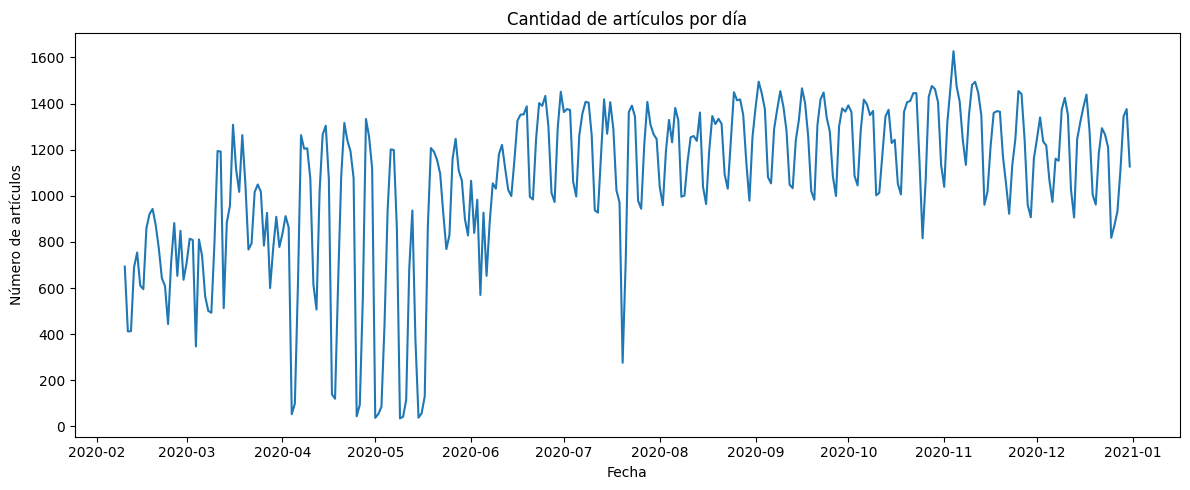

In [25]:
# Agrupar por fecha y contar artículos
articulos_por_dia = df.groupby('created_at').size()

# Graficar
plt.figure(figsize=(12, 5))
plt.plot(articulos_por_dia.index, articulos_por_dia.values)
plt.title('Cantidad de artículos por día')
plt.xlabel('Fecha')
plt.ylabel('Número de artículos')
plt.tight_layout()
plt.show()

In [26]:
# Convertir a datetime si no está hecho
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

# Filtrar años 2020-2021
df = df[(df['created_at'].dt.year >= 2020) & (df['created_at'].dt.year <= 2021)]

# Agrupar por día y contar artículos
articulos_por_dia = df.groupby('created_at').size()

# Crear un índice de fechas completo
fecha_inicio = df['created_at'].min()
fecha_fin = df['created_at'].max()
fechas_completas = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')

# Reindexar para que los días sin artículos aparezcan con 0
articulos_por_dia = articulos_por_dia.reindex(fechas_completas, fill_value=0)


In [32]:
# df_clean: tu sub-DataFrame filtrado y con Date tipo datetime
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

# Filtrar años 2020-2021
df = df[(df['created_at'].dt.year >= 2020) & (df['created_at'].dt.year <= 2021)]

# Contar artículos por día
articulos_por_dia = df.groupby('created_at').size()

# Crear índice de fechas completo
fecha_inicio = df['created_at'].min()
fecha_fin = df['created_at'].max()
fechas_completas = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')

# Reindexar para que los días sin artículos aparezcan con 0
articulos_por_dia = articulos_por_dia.reindex(fechas_completas, fill_value=0)

# Pasar a DataFrame
df_dias = articulos_por_dia.reset_index()
df_dias.columns = ['Date', 'count']

# Crear columna Año-Mes como string
df_dias['YearMonth'] = df_dias['Date'].dt.strftime('%Y-%m')

# Contar días sin artículos por mes, incluyendo meses sin huecos
dias_sin_articulos = df_dias.groupby('YearMonth').apply(lambda x: (x['count'] == 0).sum())

# Mostrar resultados
print(dias_sin_articulos)

YearMonth
2020-02    0
2020-03    0
2020-04    0
2020-05    0
2020-06    0
2020-07    0
2020-08    0
2020-09    0
2020-10    0
2020-11    0
2020-12    0
dtype: int64


C:\Users\Ceci\AppData\Local\Temp\ipykernel_10516\2006981604.py:26: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



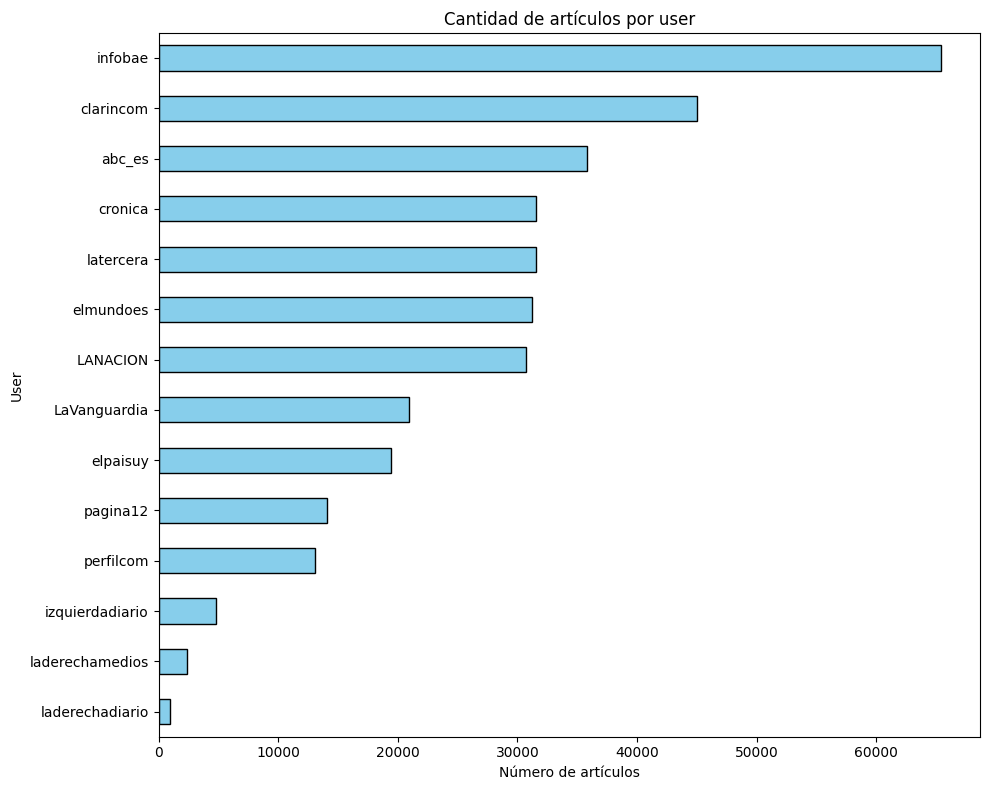

In [31]:
# Contar artículos por User
articulos_por_user = df['user'].value_counts()

top_users = articulos_por_user

# Graficar horizontal
plt.figure(figsize=(10, 8))
top_users.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Cantidad de artículos por user')
plt.xlabel('Número de artículos')
plt.ylabel('User')
plt.gca().invert_yaxis()  # Para que el top 1 quede arriba
plt.tight_layout()
plt.show()

In [33]:
print(df.body.iloc[0])

Marcelo Marchetich, ex taxista y hoy conductor de Uber, llega a su casa a las 6 de la mañana. Se baja del auto, entra y se sienta a desayunar. En unos minutos se irá a dormir. Cuenta el dinero: 3.000 pesos. Salió a las 23 e hizo alrededor de 15 viajes. Se mete en su cama con una sonrisa de satisfacción. "Los taxistas tienen que trabajar todos los días para cubrir su deuda", declara, incluso el franco "porque generalmente están atrasados", en el pago de alquiler del auto.

En la Ciudad de Buenos Aires coexisten distintos servicios de transporte. Unos, como los taxis, son tradicionales y bien conocidos por la gente, pero de acuerdo con datos de la Asociación de Taxistas de Capital (ATC), la actividad perdió 10.000 trabajadores desde 2015. "Es una barbaridad", asegura Omar Viviani, secretario general del Sindicato de Peones de Taxis (SPT). Y desgrana las críticas a las aplicaciones que no pagan impuestos mientras "el Gobierno mira para otro lado".

Como consecuencia de esta merma, el valo

Marcelo Marchetich, ex taxista y hoy conductor de Uber, llega a su casa a las 6 de la mañana. Se baja del auto, entra y se sienta a desayunar. En unos minutos se irá a dormir. Cuenta el dinero: 3.000 pesos. Salió a las 23 e hizo alrededor de 15 viajes. Se mete en su cama con una sonrisa de satisfacción. "Los taxistas tienen que trabajar todos los días para cubrir su deuda", declara, incluso el franco "porque generalmente están atrasados", en el pago de alquiler del auto.

En la Ciudad de Buenos Aires coexisten distintos servicios de transporte. Unos, como los taxis, son tradicionales y bien conocidos por la gente, pero de acuerdo con datos de la Asociación de Taxistas de Capital (ATC), la actividad perdió 10.000 trabajadores desde 2015. "Es una barbaridad", asegura Omar Viviani, secretario general del Sindicato de Peones de Taxis (SPT). Y desgrana las críticas a las aplicaciones que no pagan impuestos mientras "el Gobierno mira para otro lado".

Como consecuencia de esta merma, el valor de la licencia de taxi cayó su nivel más bajo desde principios de 2003.

Uber llegó a Argentina en 2016 y la legalidad de su operación llegó hasta la Suprema Corte

El valor de la licencia refleja el flujo esperado de trabajo. Según un relevamiento del Centro Tecnológico de Transporte, Tránsito y Seguridad Vial (C3T), de la Universidad Tecnológica Nacional (UTN), las licencias de taxis pasaron de costar unos USD15.156,33 en marzo de 2016, a USD2.890,22, en 2019. y siguieron en baja Es decir, hoy valen un 81% menos. Además, entre enero y julio de 2018 -año en que estalló la crisis económica- la licencia tuvo una caída de USD2500 aproximadamente: de 8929,37 dólares pasó a 5589,19 dólares. A partir de ahí, el descenso fue inevitable, ya que la licencia llegó a valer USD 1527,79, en julio de 2019.

Licencias poco claras

Hay un cupo limitado establecido por el Gobierno de la Ciudad de Buenos Aires, que en el último dato que ofrece se encuentra en 37.674. Para obtener una, se debe realizar una transferencia. Ésta se realiza con un escribano, quien enviará la solicitud a SACTA S.A., la empresa reguladora de la actividad que depende del Gobierno de la Ciudad. Este organismo tiene cinco días para entregar la titularidad a quien la pide, o rechazarla.

La transferencia es privada, por lo que los dueños de la licencia establecen el valor al que ellos desean venderla. "Hay una parte en negro, sin mucho control", dice Rafael Skiadaressis, especialista en economía del transporte. Además del valor propio de la licencia, el Gobierno estableció, desde 2012, una tasa a pagar al realizar una transferencia. El valor es el de 20.000 fichas de taxis. Es decir, una persona que quiere obtener una licencia de taxi debe pagar un aproximado de $91.600 por ese proceso, el 58% del valor de la licencia. Esta tasa se destina en un 80% a la capacitación de Conductores Profesionales de Taxi y en un 20% para el control de los servicios de transporte.

El factor clave de la diferencia

El valor de la licencia muestra la realidad del taxista que además ve cómo se multiplican la opciones de transporte privado. Aplicaciones como Uber, Cabify y la recién llegada Beat significan un mercado mucho más competitivo: cada vez más personas utilizan estas apps antes que el servicio de taxis.

Según el SPT, hoy en día hay 26.000 taxistas circulando. Un informe de IProUp, un portal de noticias web especializado en Fintech y startups, estima que los conductores de Uber son 55.000 y los de Cabify 12.500. La diferencia es notable, aunque las empresas no brindaron cifras oficiales que confirmen estos datos. ¿Cuál es el mayor beneficio? No es necesario tener una licencia. Al no pagar por ella ni su tasa de transferencia, los gastos se achican considerablemente.

En un contexto de crisis y desempleo, entrar en estas aplicaciones exige poco y promete una recaudación estimada en 12.000 pesos por semana, a razón de 40 horas trabajadas. Trabajar de taxista es mucho más difícil ya que implica entre 12 y 16 horas de trabajo diarias y un margen escaso de ganancia. La labor que realizan es exactamente la misma, pero los gastos que cada opción implica, hacen inclinar la balanza hacia las aplicaciones.

Un conductor de Cabify que prefirió no decir su nombre sostiene que "un gran porcentaje de conductores de la aplicación somos ex taxistas".

Lo que viene

La convivencia entre los servicios de transporte tiene visiones diferentes. Para Valeria Orso, vocera de Cabify, taxistas y aplicaciones pueden convivir porque "son distintas opciones de movilidad para los usuarios", pero remarcó que sus autos "son más seguros". Desde el SPT concuerdan en que "hay que fomentar el trabajo", pero agregan una mirada más cruda: la realidad es que es "una pelea de pobres contra pobres". En cambio, Marcelo Boeri, líder de Taxistas Unidos, dice que "avasallan su trabajo". Skiadaressis analiza que " Uber ya ganó en la forma de pedir un auto", pero ni aun con regulaciones podrían coexistir porque "las aplicaciones necesitan la flexibilidad".

Las proyecciones de crecimiento para los taxistas son inexistentes. El crecimiento de trabajadores en las aplicaciones y las largas colas de taxis vacíos no describen un panorama prometedor. La licencia seguirá bajando, y también lo hará la cantidad de choferes.

De todos modos, el futuro de las aplicaciones tampoco es una promesa de felicidad sin fin. Según Skiadaressis, las apps no existirán más cuando "los inversores privados se cansen de poner plata".

" Uber se está yendo a la B", resume al mostrar que en los últimos 5 años la empresa perdió USD12.000 millones. Si desaparecen, quedará desempleada una gran cantidad de trabajadores, mientras que en la calle circulará un servicio de taxis golpeado y disminuido. El transporte privado, seguramente, volverá al punto de reinventar nuevas opciones.